In [1]:
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import normflows as nf
import formula as fo
import summarize as su
import getplot as pl
import time

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
def make_data(n=200, p=100, sigma2=0.5, beta_signal=None, device="cpu"):
    if beta_signal is None:
        beta_signal = [1.5, -0.8, 0.7, -1.2, 0.5]

    beta_signal = torch.as_tensor(beta_signal, dtype=torch.float32, device=device)
    k = len(beta_signal)

    if k > p:
        raise ValueError("len(beta_signal) cannot exceed p")

    X = torch.randn(n, p, device=device)
    beta_true = torch.zeros(p, device=device)
    beta_true[:k] = beta_signal

    eps = math.sqrt(sigma2) * torch.randn(n, device=device)
    y = X @ beta_true + eps

    return X, y, beta_true

In [2]:
def sumfun1(model, target_dist, n_post_samples=5000, gate_threshold=0.5, inclusion_threshold=0.5,
    beta_true=None, pip_true=None, X_train=None, y_train=None, X_test=None, y_test=None,
    exact_gaussian_mean=None, exact_gaussian_cov=None, losses=None, tau_hist=None, make_plots=True,):

    t0 = time.time()

    post = su.postsum(model=model, target_dist=target_dist, n_samples=n_post_samples,
        gate_threshold=gate_threshold, inclusion_threshold=inclusion_threshold,)

    results = su.res_wrapper(post_summary=post, beta_true=beta_true,
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, pip_true=pip_true,
        exact_gaussian_mean=exact_gaussian_mean, exact_gaussian_cov=exact_gaussian_cov,)

    elapsed = time.time() - t0
    results["evaluation_time_sec"] = elapsed

    su.print_evaluation(results, post_summary=post)

    if make_plots:
        if losses is not None and tau_hist is not None:
            pl.plot_training(losses, tau_hist)

        pl.plot_posterior_inclusion_prob(
            posterior_inclusion_prob=post["pip"],
            beta_true=beta_true,
            top_k=min(30, post["pip"].numel()),
            decision_threshold=inclusion_threshold,
        )

        if beta_true is not None:
            # pick representative variables: null / signal if possible
            beta_true_cpu = fo._to_cpu(beta_true)
            nonzero_idx = torch.nonzero(beta_true_cpu != 0, as_tuple=False).squeeze(1).tolist()
            zero_idx = torch.nonzero(beta_true_cpu == 0, as_tuple=False).squeeze(1).tolist()

            chosen = []
            chosen.extend(zero_idx[:2])
            chosen.extend(nonzero_idx[:4])
            chosen = chosen[:6] if len(chosen) > 6 else chosen

            if len(chosen) > 0:
                pl.plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=False)
                pl.plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=True)

        if X_test is not None and y_test is not None:
            yhat_test_soft = X_test @ post["beta_soft_mean"]
            pl.plot_predictive_fit(y_test, yhat_test_soft, title="Test predictive fit (soft mean)")

    return post, results

In [ ]:
n = 200
p = 100
sigma2 = 0.5

X, y, beta_true = make_data(n=n, p=p, sigma2=sigma2, device=device,)

Sigma = torch.eye(p, device=device)

target_dist = fo.RelaxedSpikeSlabTarget(X=X, y=y, sigma2=sigma2, lambda_s=1.0, mu_t=0.0,
    sigma_t=1.0, tau=1.0, slab="laplace",).to(device)

flow_type = "affine_coupling"

model = fo.build_nf(latent_dim=target_dist.latent_dim, target_dist=target_dist,
    flow_type=flow_type, K=8, hidden_units=128, num_hidden_layers=2, device=device,)

losses, tau_hist = fo.train_flow(model=model, target_dist=target_dist,
    epochs=6000, num_samples=1024, lr=1e-3, tau_start=1.0, tau_end=0.1,
    kl_anneal=False, grad_clip=5.0, print_every=500,)

torch.save({"model_state_dict": model.state_dict(), "flow_type": flow_type, "latent_dim": target_dist.latent_dim,
    "K": 8, "hidden_units": 128, "num_hidden_layers": 2, "sigma2": sigma2, "losses": losses, 
    "tau_hist": tau_hist, "beta_true": beta_true, "X": X, "y": y,}, "run1_checkpoint.pt")


epoch     1 | loss = 7819.1797 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 205.3391 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 204.3805 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 194.3418 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 190.1717 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 188.8138 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 192.3062 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 189.6129 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 191.2571 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 190.2218 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 187.1958 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 189.6785 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 188.4831 | tau = 0.1000 | anneal_beta = 1.0000


In [3]:
ckpt = torch.load("run1_checkpoint.pt", map_location=device)

X = ckpt["X"].to(device)
y = ckpt["y"].to(device)
beta_true = ckpt["beta_true"].to(device)
sigma2 = ckpt["sigma2"]
flow_type = ckpt["flow_type"]
K = ckpt["K"]
hidden_units = ckpt["hidden_units"]
num_hidden_layers = ckpt["num_hidden_layers"]
losses = ckpt["losses"]
tau_hist = ckpt["tau_hist"]

target_dist = fo.RelaxedSpikeSlabTarget(X=X, y=y, sigma2=sigma2, lambda_s=1.0, mu_t=0.0, sigma_t=1.0, tau=1.0, slab="laplace",).to(device)

model = fo.build_nf(target_dist.latent_dim, target_dist, flow_type, K, hidden_units, num_hidden_layers, device,)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0-7): 8 x MaskedAffineFlow(
      (s): MLP(
        (net): Sequential(
          (0): Linear(in_features=201, out_features=128, bias=True)
          (1): LeakyReLU(negative_slope=0.0)
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): LeakyReLU(negative_slope=0.0)
          (4): Linear(in_features=128, out_features=201, bias=True)
        )
      )
      (t): MLP(
        (net): Sequential(
          (0): Linear(in_features=201, out_features=128, bias=True)
          (1): LeakyReLU(negative_slope=0.0)
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): LeakyReLU(negative_slope=0.0)
          (4): Linear(in_features=128, out_features=201, bias=True)
        )
      )
    )
  )
  (p): RelaxedSpikeSlabTarget()
)


EVALUATION SUMMARY

[support_soft]
  - tp: 5
  - fp: 0
  - fn: 0
  - tn: 95
  - precision: 1.0
  - recall: 1.0
  - f1: 1.0
  - specificity: 1.0
  - fpr: 0.0
  - mcc: 1.0
  - auroc_pip: 1.0
  - auprc_pip: 1.0

[beta_soft_mean]
  - l1_error: 0.1371098905801773
  - l2_error: 0.06297041475772858
  - linf_error: 0.044080257415771484
  - rel_l2_error: 0.027966142770377327

[beta_hard_mean]
  - l1_error: 0.40204039216041565
  - l2_error: 0.18943655490875244
  - linf_error: 0.13423681259155273
  - rel_l2_error: 0.08413172695287634

[prediction_soft]

[prediction_hard]

[evaluation_time_sec]
0.9093868732452393

[posterior quick look]
selected_idx: [0, 1, 2, 3, 4]
first PIPs: tensor([9.9900e-01, 9.9980e-01, 9.7240e-01, 1.0000e+00, 8.8180e-01, 0.0000e+00,
        0.0000e+00, 4.0000e-04, 0.0000e+00, 2.0000e-04, 0.0000e+00, 4.0000e-04,
        2.0000e-04, 2.0000e-04, 0.0000e+00, 2.0000e-04, 0.0000e+00, 0.0000e+00,
        2.0000e-04, 6.0000e-04])
first beta_soft_mean: tensor([ 1.4559e+00, -8.2571e

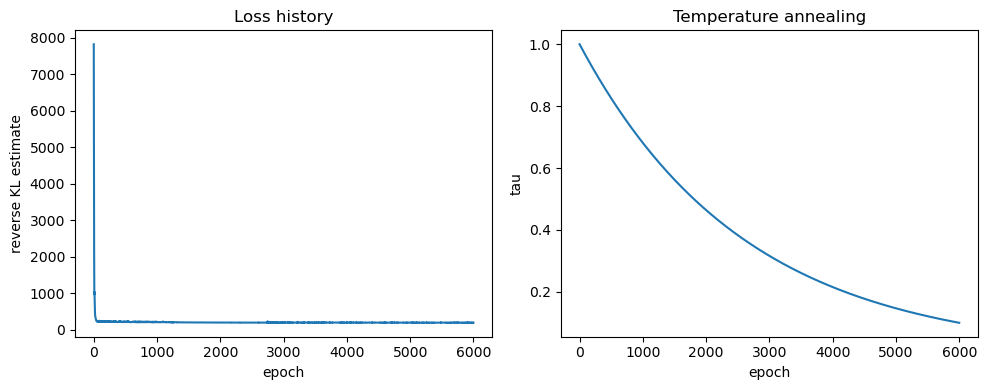

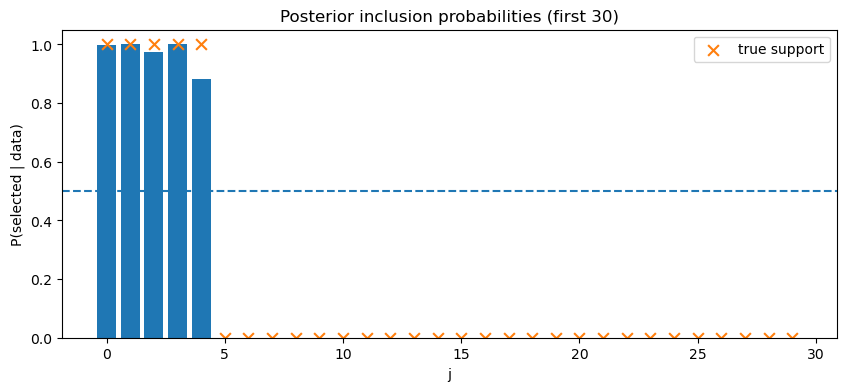

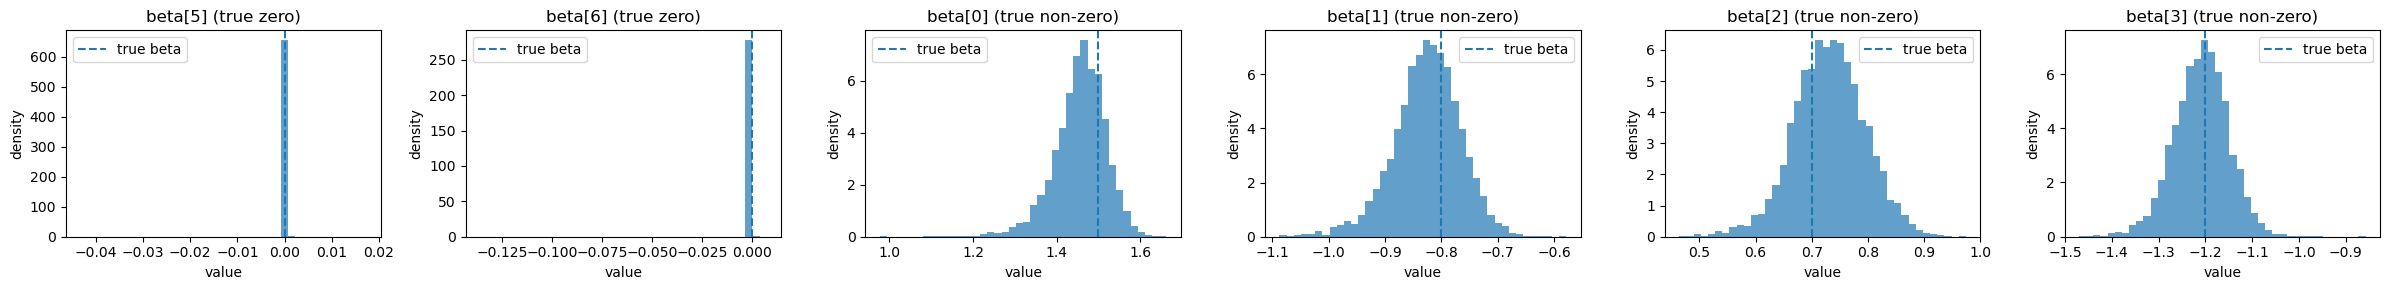

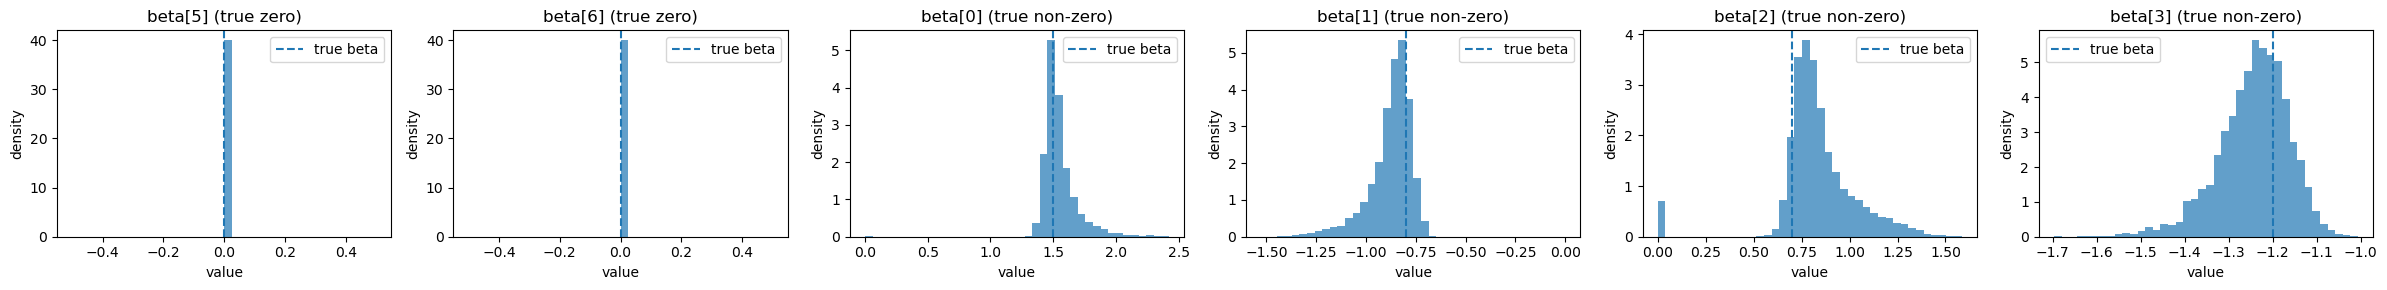

In [4]:
post, results = sumfun1(model=model, target_dist=target_dist, n_post_samples=5000, gate_threshold=0.5, inclusion_threshold=0.5,
    beta_true=beta_true, pip_true=None, X_train=None, y_train=None, X_test=None, y_test=None,
    exact_gaussian_mean=None, exact_gaussian_cov=None, losses=losses, tau_hist=tau_hist, make_plots=True,)